# Projeto 02 — K-Means

**Disciplina:** GCC 128 — Inteligência Artificial  
**Instituição:** Universidade Federal de Lavras (UFLA)  
**Docentes:** Prof. Ahmed Ali Abdalla Esmin  
**Discentes:** Caio Bueno Finocchio Martins e Lana da Silva Miranda

## 1. Importação e Preparação dos Dados

A base Iris contém medidas de sépalas e pétalas de três espécies de flores. Nesta seção, os dados são carregados e preparados para a execução manual do K-Means.

In [1]:
import random
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
file_path = "Iris.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/iris",
  file_path,
)

df.head()

C:\Users\caiof\AppData\Local\Temp\ipykernel_5536\1731974164.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Cada amostra possui quatro atributos numéricos: comprimento e largura da sépala, e comprimento e largura da pétala. A coluna `Species` identifica a espécie, mas não será utilizada pelo K-Means.

In [3]:
colunas_atributos = [
    'SepalLengthCm',
    'SepalWidthCm',
    'PetalLengthCm',
    'PetalWidthCm'
]

dados = df[colunas_atributos].values.tolist()
rotulos = df['Species'].tolist()

print(f"Quantidade total de amostras: {len(dados)}")
print(f"Exemplo de atributos: {dados[0]}")
print(f"Exemplo de rótulo: {rotulos[0]}")

Quantidade total de amostras: 150
Exemplo de atributos: [5.1, 3.5, 1.4, 0.2]
Exemplo de rótulo: Iris-setosa


## 2. Execução Inicial do K-Means

O algoritmo associa cada ponto ao centróide mais próximo e recalcula os centróides pela média dos grupos até atingir a convergência.

### 2.1 Implementação do K-Means

Pseudocódigo do processo iterativo:

```
Escolha inicialmente k centros
repita:
    para cada ponto:
        descubra qual centro está mais perto
        coloque o ponto nesse grupo
    para cada grupo:
        calcule novamente seu centro
        usando a média dos pontos
até que os grupos/centróides parem de mudar
```

In [4]:
# distancia euclidiana entre dois pontos
def distancia_euclidiana(entrada, dado):
    distancia = 0
    for i in range(len(entrada)):
        distancia += (entrada[i] - dado[i])**2
    return distancia**0.5

In [5]:
# encontra o centroide mais próximo de um dado ponto
def achar_centroide(dado, centroides):
    menor = float('inf')
    centroide_escolhido = None

    for centroide in centroides:
        dist = distancia_euclidiana(dado, centroide)
        if dist < menor:
            menor = dist
            centroide_escolhido = centroide

    return centroide_escolhido


# adiciona um dado a um grupo específico, associa ao centroide mais próximo
def add_ao_grupo(dado, centroide, centroides, grupos):
    indice = centroides.index(centroide)
    grupos[f"grupo{indice+1}"].append(dado)

In [6]:
# recalcula os centroides com base nos grupos formados
def recalcular_centroides(grupos, centroides):
    novos_centroides = []

    for i in range(len(centroides)):
        grupo_key = f"grupo{i+1}"
        grupo_atual = grupos[grupo_key]

				# Calcula o centroide médio (average) do grupo atual
        if len(grupo_atual) > 0:
            centroide_medio = [0.0] * len(centroides[i])

            for dado in grupo_atual:
                for j in range(len(dado)):
                    centroide_medio[j] += dado[j]

            for j in range(len(centroide_medio)):
                centroide_medio[j] /= len(grupo_atual)

            novos_centroides.append(centroide_medio)
        else:
            novos_centroides.append(list(centroides[i]))

    return novos_centroides

### Algoritmo K-Means

In [7]:
def kmeans(dados, k, seed=42, max_iter=100):
    gerador = random.Random(seed)
    amostras_iniciais = gerador.sample(dados, k)
    centroides = [list(amostra) for amostra in amostras_iniciais]

    grupos = {f"grupo{i+1}": [] for i in range(k)}
    iteracoes = 0

    for iteracao in range(1, max_iter + 1):
        iteracoes = iteracao
        grupos = {f"grupo{i+1}": [] for i in range(k)}

        for dado in dados:
            centroide = achar_centroide(dado, centroides)
            add_ao_grupo(dado, centroide, centroides, grupos)

        novos_centroides = recalcular_centroides(grupos, centroides)

        if centroides == novos_centroides:
            break

        centroides = novos_centroides

    return centroides, grupos, iteracoes

### 2.2 Execução com os Dados Originais



In [8]:
centroides, grupos, iteracoes = kmeans(dados, k=2, seed=42, max_iter=100)

print("Centroides finais:")
for i, centroide in enumerate(centroides):
    print(f"Centróide {i + 1}: {centroide}")

print(f"Número de iterações: {iteracoes}")

Centroides finais:
Centróide 1: [6.30103092783505, 2.8865979381443303, 4.958762886597939, 1.6958762886597945]
Centróide 2: [5.005660377358491, 3.360377358490567, 1.562264150943396, 0.2886792452830188]
Número de iterações: 4


## 3. Métricas Iniciais

### 3.1 Silhouette Score

O **Silhouette Score** compara a coesão de cada ponto com a separação em relação aos demais clusters, variando de -1 a 1, com valores maiores indicando uma melhor separação.

In [9]:
def calcular_wcss(grupos, centroides):
    wcss = 0.0

    for i, centroide in enumerate(centroides):
        grupo = grupos[f"grupo{i+1}"]

        for dado in grupo:
            distancia = distancia_euclidiana(dado, centroide)
            wcss += distancia**2

    return wcss


def obter_rotulos_clusters(dados, centroides):
    rotulos_clusters = []

    for dado in dados:
        centroide = achar_centroide(dado, centroides)
        rotulos_clusters.append(centroides.index(centroide))

    return rotulos_clusters

### 3.2 WCSS

O **WCSS (inércia)** mede a soma das distâncias quadráticas entre os pontos e os centroides de seus grupos; valores menores indicam grupos mais compactos.

$$
\mathrm{WCSS} = \sum_{i=1}^{n} \left\|x_i - c_i\right\|^2
$$


In [10]:
valores_k = list(range(1, 11))
wcss_original = []
silhouette_original = {}

for k in valores_k:
    centroides_k, grupos_k, iteracoes_k = kmeans(dados, k=k, seed=42, max_iter=100)

    wcss = calcular_wcss(grupos_k, centroides_k)
    wcss_original.append(wcss)

    print(f"K={k:2d} | WCSS={wcss:.4f}", end="")

    if k >= 2:
        rotulos_clusters = obter_rotulos_clusters(dados, centroides_k)
        silhouette = silhouette_score(dados, rotulos_clusters)
        silhouette_original[k] = silhouette
        print(f" | Silhouette={silhouette:.4f}")
    else:
        print(" | Silhouette=não aplicável")

K= 1 | WCSS=680.8244 | Silhouette=não aplicável
K= 2 | WCSS=152.3687 | Silhouette=0.6808
K= 3 | WCSS=142.8593 | Silhouette=0.5167
K= 4 | WCSS=71.3404 | Silhouette=0.4171
K= 5 | WCSS=49.7408 | Silhouette=0.3760
K= 6 | WCSS=49.0271 | Silhouette=0.3362
K= 7 | WCSS=46.8801 | Silhouette=0.3376
K= 8 | WCSS=42.6175 | Silhouette=0.3234
K= 9 | WCSS=42.3244 | Silhouette=0.3207
K=10 | WCSS=31.5682 | Silhouette=0.3234


## 4. Padronização dos Dados

A padronização coloca os atributos em escalas comparáveis. Isso é especialmente relevante para o K-Means, pois o algoritmo utiliza a distância euclidiana e atributos com escalas maiores podem exercer influência desproporcional.

In [11]:
scaler = StandardScaler()
dados_padronizados = scaler.fit_transform(dados).tolist()

for i in range(3):
    print(f"Observação {i + 1}")
    print(f"Original:     {dados[i]}")
    print(f"Padronizada:  {dados_padronizados[i]}")
    print()

Observação 1
Original:     [5.1, 3.5, 1.4, 0.2]
Padronizada:  [-0.9006811702978099, 1.0320572244889554, -1.3412724047598341, -1.3129767272601454]

Observação 2
Original:     [4.9, 3.0, 1.4, 0.2]
Padronizada:  [-1.1430169111851116, -0.12495760117131036, -1.3412724047598341, -1.3129767272601454]

Observação 3
Original:     [4.7, 3.2, 1.3, 0.2]
Padronizada:  [-1.3853526520724144, 0.3378483290927964, -1.3981381087490865, -1.3129767272601454]



## 5. K-Means com Dados Padronizados

Nesta etapa, o mesmo K-Means manual é avaliado após a padronização dos atributos, mantendo os parâmetros do experimento com os dados originais para permitir comparações posteriores.

In [12]:
wcss_padronizado = []
silhouette_padronizado = {}

for k in valores_k:
    centroides_k, grupos_k, iteracoes_k = kmeans(dados_padronizados, k=k, seed=42, max_iter=100)

    wcss = calcular_wcss(grupos_k, centroides_k)
    wcss_padronizado.append(wcss)

    print(f"K={k:2d} | WCSS={wcss:.4f}", end="")

    if k >= 2:
        rotulos_clusters = obter_rotulos_clusters(dados_padronizados, centroides_k)
        silhouette = silhouette_score(dados_padronizados, rotulos_clusters)
        silhouette_padronizado[k] = silhouette
        print(f" | Silhouette={silhouette:.4f}")
    else:
        print(" | Silhouette=não aplicável")

K= 1 | WCSS=600.0000 | Silhouette=não aplicável
K= 2 | WCSS=223.7320 | Silhouette=0.5802
K= 3 | WCSS=192.0372 | Silhouette=0.4787
K= 4 | WCSS=114.6822 | Silhouette=0.3872
K= 5 | WCSS=91.2578 | Silhouette=0.3443
K= 6 | WCSS=82.0045 | Silhouette=0.3443
K= 7 | WCSS=81.0411 | Silhouette=0.2993
K= 8 | WCSS=74.1736 | Silhouette=0.2886
K= 9 | WCSS=73.1448 | Silhouette=0.2641
K=10 | WCSS=66.7095 | Silhouette=0.2340


## 6. Método do Cotovelo e Silhouette

O Método do Cotovelo procura uma região em que a redução do WCSS começa a perder intensidade, auxiliando na escolha de K. No Silhouette Score, valores maiores indicam clusters mais coesos e bem separados.

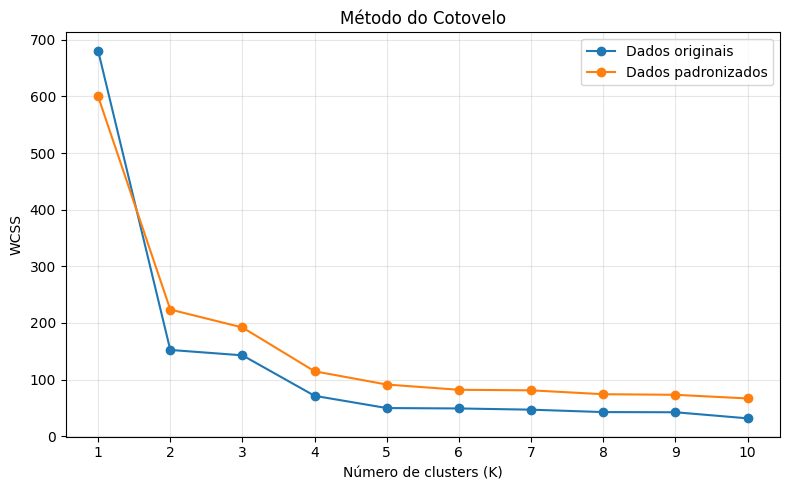

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    valores_k,
    wcss_original,
    marker='o',
    label='Dados originais'
)
plt.plot(
    valores_k,
    wcss_padronizado,
    marker='o',
    label='Dados padronizados'
)
plt.title('Método do Cotovelo')
plt.xlabel('Número de clusters (K)')
plt.ylabel('WCSS')
plt.xticks(valores_k)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

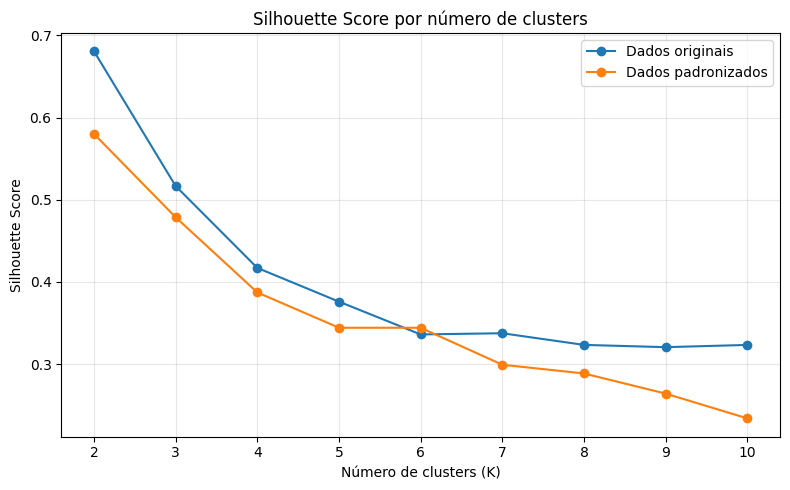

In [14]:
valores_k_silhouette = valores_k[1:]

plt.figure(figsize=(8, 5))
plt.plot(
    valores_k_silhouette,
    [silhouette_original[k] for k in valores_k_silhouette],
    marker='o',
    label='Dados originais'
)
plt.plot(
    valores_k_silhouette,
    [silhouette_padronizado[k] for k in valores_k_silhouette],
    marker='o',
    label='Dados padronizados'
)
plt.title('Silhouette Score por número de clusters')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(valores_k_silhouette)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Visualização dos Clusters

O PCA reduz os quatro atributos padronizados para duas componentes principais, permitindo visualizar as observações em um plano. O primeiro gráfico utiliza os clusters encontrados pelo K-Means manual. Os rótulos reais são usados somente no segundo gráfico para comparação visual e não participaram da execução do K-Means.

$$
PC1 = a \cdot SepalLength +
b \cdot SepalWidth +
c \cdot PetalLength +
d \cdot PetalWidth
$$

In [15]:
pca = PCA(n_components=2)

# Representação : transformação dos dados padronizados para 2 dimensões usando PCA
dados_pca = pca.fit_transform(dados_padronizados)

# Clustering
centroides_visualizacao, grupos_visualizacao, iteracoes_visualizacao = kmeans(dados_padronizados, k=2, seed=42, max_iter=100)

rotulos_clusters_kmeans = obter_rotulos_clusters(dados_padronizados, centroides_visualizacao)

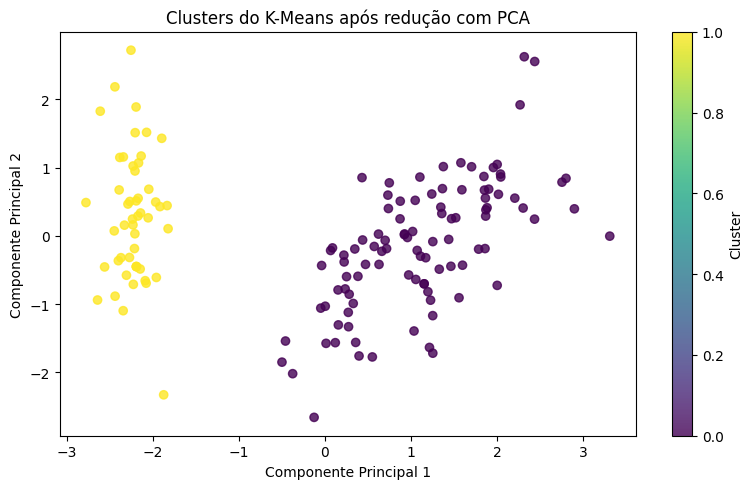

In [16]:
plt.figure(figsize=(8, 5))
dispersao_clusters = plt.scatter(
    dados_pca[:, 0],
    dados_pca[:, 1],
    c=rotulos_clusters_kmeans,
    cmap='viridis',
    alpha=0.8
)
plt.title('Clusters do K-Means após redução com PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(dispersao_clusters, label='Cluster')
plt.tight_layout()
plt.show()

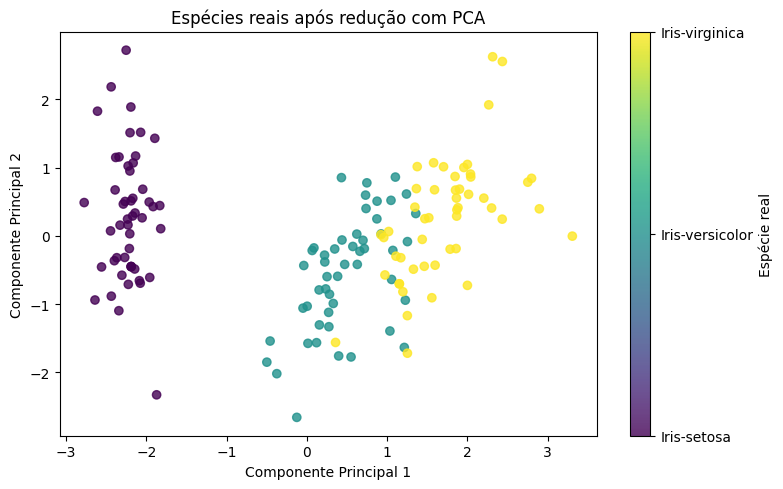

In [17]:
especies = sorted(set(rotulos))
mapa_especies = {
    especie: indice for indice, especie in enumerate(especies)
}
rotulos_reais_numericos = [mapa_especies[rotulo] for rotulo in rotulos]

plt.figure(figsize=(8, 5))
dispersao_especies = plt.scatter(
    dados_pca[:, 0],
    dados_pca[:, 1],
    c=rotulos_reais_numericos,
    cmap='viridis',
    alpha=0.8
)
plt.title('Espécies reais após redução com PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

barra_cores = plt.colorbar(dispersao_especies, ticks=range(len(especies)))
barra_cores.set_label('Espécie real')
barra_cores.set_ticklabels(especies)

plt.tight_layout()
plt.show()

## 8. Análise e Conclusão

### 8.1 Influência de K e avaliação dos agrupamentos

O WCSS diminui à medida que K aumenta, pois a criação de mais grupos reduz a distância entre as observações e seus respectivos centroides. No Método do Cotovelo, a maior queda inicial ocorre de K=1 para K=2. Entretanto, a curva não apresenta um cotovelo completamente inequívoco, o que dificulta a escolha de K apenas por esse critério.

O Silhouette Score fornece uma indicação mais clara neste experimento. K=2 apresentou o maior valor tanto para os dados originais (0.6808) quanto para os dados padronizados (0.5802), indicando que essa configuração produziu os grupos mais coesos e separados entre os valores de K avaliados.

### 8.2 Efeito da padronização e análise visual

A padronização coloca os atributos em escalas comparáveis e, assim, altera a influência de cada atributo no cálculo das distâncias euclidianas. Neste experimento, porém, ela não aumentou o Silhouette Score. Além disso, os valores absolutos de WCSS obtidos antes e depois da padronização não devem ser comparados diretamente, pois foram calculados sobre dados em escalas diferentes.

A visualização com PCA mostra uma separação forte de um grupo e maior sobreposição entre os demais. Na comparação com as espécies reais, a *Iris-setosa* aparece bastante separada, enquanto *Iris-versicolor* e *Iris-virginica* apresentam maior proximidade. Esse comportamento ajuda a explicar por que K=2 obteve o melhor Silhouette Score, embora a base contenha três espécies. As espécies reais foram utilizadas somente para comparação visual e não foram fornecidas como entrada ao K-Means.

### 8.3 Limitações e conclusão

Entre as limitações do K-Means estão a necessidade de definir K previamente, a sensibilidade à escala dos atributos e aos centroides iniciais, além da dificuldade para representar grupos sobrepostos ou com formatos diferentes. A visualização por PCA também pode provocar perda de informação ao reduzir os quatro atributos para apenas duas dimensões.

Para os experimentos realizados, K=2 apresentou a melhor separação segundo o Silhouette Score. A comparação com as três espécies reais reforça que agrupamentos não supervisionados identificam estruturas nos atributos e, portanto, não precisam coincidir com classes previamente conhecidas.